# Experiment 3 — Entity/Record-Resolution Error Propagation & the Honest Confidence Interval

**Companion:** implementation guide §13.3 · design document §5.6 (Theorem 4 + Corollary 2).
**Query:** *"How many points did LeBron James score in each game of the 2018 NBA Playoffs, and what was his playoff PPG?"*

### What this experiment shows
We report the aggregate (here, **SUM of points**, with **PPG = SUM / games**) as
$$\widehat{\text{SUM}} \;\pm\; \big(\underbrace{z\,\sigma_{\text{value}}}_{\text{value}} + \underbrace{\varepsilon_{ER}(\bar v_{\text{split}}+\bar v_{\text{merge}})}_{\text{join}} + \underbrace{\varepsilon\cdot\text{SUM}}_{\text{completeness}}\big)$$
and check that this 3‑part interval **covers** the true total. We then **degrade the matcher** (lower $\tau_+$) to make the *join* term widen, and confirm coverage still holds. That is exactly Theorem 4 (bounded‑error join) feeding Corollary 2 (honest interval).

### Two things to know before reading the numbers
1. **Theorem numbering.** The guide labels this *"Theorem 3"*; those are the guide's internal labels and are off‑by‑one vs the design doc, where the entity‑join bound is **Theorem 4** and the honest interval is **Corollary 2** (design‑doc Theorem 3 is the *schema‑addressable* result = Experiment 4). We use the design‑doc numbers.
2. **Single‑entity adaptation.** The guide built Exp 3 around the multi‑entity *Alphabet* query, where $\tau_+$ governs **entity** resolution ("Acme Corp" = "ACME"?). The LeBron query has **one entity** (LeBron James) but **many records** (22 games). So the join that matters is **record** resolution: which mention belongs to which *game*, keyed on `(date, opponent)` — the same role `(amount, date)` plays for funding rounds (design §5.5). Because each game has a **unique date**, record resolution here is naturally robust, so the *realized* answer barely moves with $\tau_+$. What the sweep then demonstrates is the **reported‑bound** side: the interval covers, and its join term grows as the matcher is assumed worse. On a query with colliding keys (two subsidiaries sharing a name) the realized answer itself would drift and coverage would be the binding check — both behaviours are correct.

> **💸 Cost.** Step 2 calls the **real Serper API** and the **real extraction LLM** (no offline stub). It caches its corpus to `data/runs/<run_id>.corpus.json` and is **idempotent**: the paid collection runs **once**; the $\tau_+$ sweep afterwards is pure local compute and free to re‑run.

## Setup
Locate the repo root, `chdir` into it (so the relative `prompts/…` paths inside `extract.py` resolve and `.env` is found), put the package and `scripts/` on the path, and import the experiment module. All heavy/networked imports (Serper, the LLM client, sentence‑transformers) live *inside* `eval_er`'s functions, so this import is cheap, key‑free, and torch‑free.

In [30]:
import os, sys
from pathlib import Path

# Walk up from the notebook's location until we find the repo root (it contains prompts/ and webagg/).
REPO = Path.cwd()
while not ((REPO / "prompts").exists() and (REPO / "webagg").exists()) and REPO != REPO.parent:
    REPO = REPO.parent
assert (REPO / "prompts").exists(), "Run this notebook from inside the webagg repo."

os.chdir(REPO)                                   # prompts/relevance.txt etc. are opened by relative path
sys.path.insert(0, str(REPO))                    # so `import webagg.*` works
sys.path.insert(0, str(REPO / "scripts"))        # so `import eval_er` works
import eval_er                                    # the Experiment-3 module (scripts/eval_er.py)

import pandas as pd
pd.set_option("display.width", 160, "display.max_columns", 30)
print("repo root:", REPO)

# ---- Experiment configuration (edit these to run a different query) --------
QUERY        = ("How many points did LeBron James score in each game of the 2018 NBA Playoffs, "
                "and what was his playoff points-per-game?")
GT_PATH      = REPO / "data" / "ground_truth" / "lebron_2018_playoffs_ppg.json"
RECORD_FIELDS = eval_er.LEBRON_RECORD_FIELDS      # {"key": ["date","opponent"], "aggregate": "points", "entity": None}
ENTITY_NAME  = "LeBron James"
RUN_ID       = "exp3_lebron"                       # names the cached corpus + the figure
TAUS         = (0.9, 0.8, 0.7)                     # matcher thresholds to sweep (lower = worse matcher)
EPS          = 0.10                                # completeness slack (feeds the recall term; design §2)
DELTA        = 0.10                                # confidence: pass if coverage >= 1 - DELTA of thresholds
KEY, AGG     = RECORD_FIELDS["key"], RECORD_FIELDS["aggregate"]
RECORD_FIELDS

repo root: D:\Projects\webagg


{'key': ['date', 'opponent'], 'aggregate': 'points', 'entity': None}

## Step 1 — Load the ground truth
The ground‑truth file lists the true records (one per game). For Exp 3 the quantity under test is the **aggregate**: `true_sum` (= 748) and, since this is one entity with one record per game, the implied `true_mean = SUM / N` (= the true PPG, 34.0). `load_ground_truth` also reports `single_entity` (True here) by counting distinct `entity_canonical` values — that flag is what later tells the resolver to skip entity matching and go straight to record (game) resolution.

In [31]:
gt = eval_er.load_ground_truth(str(GT_PATH), AGG)     # parses the file and computes the true aggregate
print(f"true SUM      = {gt['true_sum']:g}")
print(f"true records  = {gt['true_n']}")
print(f"true mean/PPG = {gt['true_mean']:.2f}")
print(f"single_entity = {gt['single_entity']}  (entities: {sorted(gt['entities'])})")

true SUM      = 748
true records  = 22
true mean/PPG = 34.00
single_entity = True  (entities: ['LeBron James'])


## Step 2 — Collect the corpus (REAL Serper + REAL extraction LLM)
This is the only paid step. Following the design doc's fetch/extract worker (§8):
**seed formulations** (LLM proposes diverse searches) → **search** (Serper) → **fetch** (HTTP + trafilatura) → **relevance filter** (LLM) → **record extraction** (LLM). Everything is stored with provenance (`source_id`, domain, timestamps, the verbatim passage), because the corroboration layer (Step 4) reads it.

One deliberate deviation from `run_query`'s flat extraction: a single game‑log page lists *all 22 games*, and a flat `(attribute, value)` schema can't tie `points=24` to `date=2018-04-15`. So we extract **records** — one row per game, each carrying its key attributes (`date`, `opponent`) **and** its aggregate value (`points`) together. That keeps a game's identity and its number linked, which is the unit record resolution + corroboration need.

The result is cached. Set `force=True` only to re‑pull from the web.

In [32]:
corpus = eval_er.collect_and_extract(
    QUERY, RUN_ID, RECORD_FIELDS,
    entity_name=ENTITY_NAME,
    single_entity=gt["single_entity"],   # True -> skips entity matching (and torch) entirely
    force=False,                          # idempotent: reuses data/runs/<RUN_ID>.corpus.json if present
)
print(f"corpus: {len(corpus['sources'])} sources, {len(corpus['mentions'])} record-mentions "
      f"(cached at data/runs/{RUN_ID}.corpus.json)")

[collect] using cached corpus exp3_lebron.corpus.json (no API calls)
corpus: 4 sources, 66 record-mentions (cached at data/runs/exp3_lebron.corpus.json)


## Step 3 — Inspect what we collected (sanity before resolving)
Before resolution, look at the raw record‑mentions: how many came from each source domain (these are the *echoes* corroboration will collapse), and how many **distinct `(date, opponent)` keys** we found versus the 22 true games. If distinct keys $\ll$ 22 the search/extraction missed games (a recall problem, not a resolution one); if $\gg$ 22 the extractor produced noisy/dirty keys that record resolution will need to merge.

In [33]:
dom_of = {sid: s["domain"] for sid, s in corpus["sources"].items()}
mdf = pd.DataFrame([{
    "domain": dom_of[m["source_id"]],
    **{k: m["fields"].get(k) for k in KEY},   # the key attrs (date, opponent)
    AGG: m["agg_value"],                      # the aggregate value (points)
} for m in corpus["mentions"]])

print(f"record-mentions: {len(mdf)}\n")
print("by source domain (these are the echoes corroboration will dedupe):")
print(mdf["domain"].value_counts().to_string(), "\n")
distinct_keys = mdf[KEY].drop_duplicates().shape[0]
print(f"distinct {tuple(KEY)} keys found: {distinct_keys}   (true games: {gt['true_n']})")
mdf.head(8)

record-mentions: 66

by source domain (these are the echoes corroboration will dedupe):
domain
www.statmuse.com    66 

distinct ('date', 'opponent') keys found: 44   (true games: 22)


,domain,date,opponent,points
0,www.statmuse.com,6/8/2018,None,23
1,www.statmuse.com,6/6/2018,None,33
2,www.statmuse.com,6/3/2018,None,29
3,www.statmuse.com,5/31/2018,None,51
4,www.statmuse.com,5/27/2018,None,35
5,www.statmuse.com,5/25/2018,None,46
6,www.statmuse.com,5/23/2018,None,26
7,www.statmuse.com,5/21/2018,None,44


## Step 4 — Resolution + corroboration at one threshold (the mechanics)
We walk through a single $\tau_+$ (= 0.9) to see the join in action. Two levels (design §5.2):

- **Entity resolution** — trivial here (one entity), so every mention is grouped under `LeBron James`. (On a multi‑entity query this is where `cluster_entities` would run with the swept $\tau_+$.)
- **Record resolution** — *within* the entity, merge two mentions into the same **game** iff their key similarity $\ge \tau_+$. Think of it as a `GROUP BY` on an inferred key: `date` is the discriminative column (different games are $\ge 2$ days apart, so they never falsely merge), with `opponent` a weak tiebreaker. Connected components of the merge graph are the distinct games (design §5.4, simplified to connected components for the prototype).

Then **corroboration** (design §3.4, Algorithm 2) picks one value per game via noisy‑OR over *independent* witnesses: `nu` is the number of independent sources (echoes of one press release collapse to 1), so the SUM isn't inflated and belief reflects genuine corroboration (Theorem 2). `belief` here drives the *value* term of the interval.

In [34]:
resolved, _ = eval_er.resolve(corpus, 0.9, KEY, AGG, eval_er.KEY_WEIGHTS)
rdf = (pd.DataFrame([{**r["key"],
                      "value": r["value"], "belief": round(r["belief"], 3),
                      "nu": r["nu"], "n_mentions": r["n_mentions"]} for r in resolved])
       .sort_values(KEY).reset_index(drop=True))

resolved_sum = sum(r["value"] for r in resolved)
print(f"resolved games: {len(resolved)}   (true: {gt['true_n']})")
print(f"resolved SUM  : {resolved_sum:g}   ->  PPG = {resolved_sum / max(len(resolved),1):.2f}")
print("(nu = independent witnesses; n_mentions = raw echoes before dedup)\n")
rdf

resolved games: 66   (true: 22)
resolved SUM  : 2244   ->  PPG = 34.00
(nu = independent witnesses; n_mentions = raw echoes before dedup)



,date,opponent,value,belief,nu,n_mentions
0,4/15/2018,vs,24.0,0.5,1,1
1,4/15/2018,None,24.0,0.5,1,1
2,4/15/2018,None,24.0,0.5,1,1
3,4/18/2018,vs,46.0,0.5,1,1
4,4/18/2018,None,46.0,0.5,1,1
...,...,...,...,...,...,...
61,6/6/2018,None,33.0,0.5,1,1
62,6/6/2018,None,33.0,0.5,1,1
63,6/8/2018,vs,23.0,0.5,1,1
64,6/8/2018,None,23.0,0.5,1,1


## Step 5 — The three‑part confidence interval (Corollary 2)
The interval makes the three error sources explicit:

- **value** $= z\sqrt{\sum v^2(1-\text{belief})^2}$ — uncertainty from weakly‑corroborated values (smaller when the real sources are independent, so `nu` is high and `belief` $\to 1$).
- **join** $= \varepsilon_{ER}(\bar v_{\text{split}} + \bar v_{\text{merge}})$ — the resolution error of Theorem 4.
- **completeness** $= \varepsilon\cdot\text{SUM}$ — the unseen‑mass slack from the stopping rule (Theorem 1).

**Deviation worth flagging:** the guide hard‑codes $\varepsilon_{ER}=0.05$, so its join term is *constant* and the sweep wouldn't actually show Theorem 4's bound responding to a worse matcher. We instead map $\tau_+ \to \varepsilon_{ER}$ monotonically (`eps_er_for_tau`): lowering $\tau_+$ widens the auto‑merge zone and shrinks the LLM‑adjudicated band, so the per‑pair false‑merge rate $\alpha$ rises → a larger $\varepsilon_{ER}$. That is precisely the guide's instruction to "degrade $\tau_+$ to **widen** the bound", made quantitative.

In [35]:
eps_er = eval_er.eps_er_for_tau(0.9)                       # join coefficient implied by this threshold
ci = eval_er.aggregate_with_ci(resolved, eps=EPS, eps_er=eps_er)
for k in ("answer", "n_records", "value_term", "join_term", "recall_term", "ci_total"):
    print(f"{k:12} = {ci[k]:.2f}" if isinstance(ci[k], float) else f"{k:12} = {ci[k]}")
print(f"\nPPG = SUM / n = {ci['answer']/ci['n_records']:.2f}")
print(f"covers truth? |{ci['answer']:.0f} - {gt['true_sum']:.0f}| = "
      f"{abs(ci['answer']-gt['true_sum']):.1f}  <=  CI {ci['ci_total']:.1f}  ->  "
      f"{abs(ci['answer']-gt['true_sum']) <= ci['ci_total']}")

answer       = 2244.00
n_records    = 66
value_term   = 281.41
join_term    = 3.40
recall_term  = 224.40
ci_total     = 509.21

PPG = SUM / n = 34.00
covers truth? |2244 - 748| = 1496.0  <=  CI 509.2  ->  False


## Step 6 — The $\tau_+$ sweep and the coverage test (the actual Exp‑3 protocol)
Now repeat resolve → corroborate → aggregate → CI for each $\tau_+ \in$ `TAUS`, and check the pass condition: **`abs_err <= ci_total`** at every threshold. As noted up top, with unique game dates the `answer` stays ~748 across $\tau_+$ (record resolution is robust here); what moves is `eps_ER` and hence the `join_term`. The binding observation for this query is therefore *coverage holds while the join term widens*. (`mean`/`mean_ci` are the per‑game PPG and its implied interval, for convenience.)

In [36]:
df = eval_er.run_sweep(corpus, gt, taus=TAUS, eps=EPS, record_fields=RECORD_FIELDS)
df  # one row per tau_plus

,tau_plus,eps_ER,answer,n_records,true_sum,abs_err,value_term,join_term,recall_term,ci_total,covered,mean,true_mean,mean_ci
0,0.9,0.050,2244.0,66,748.0,1496.0,281.411910,3.4,224.4,509.211910,False,34.0,34.0,7.715332
1,0.8,0.125,2244.0,66,748.0,1496.0,281.411910,8.5,224.4,514.311910,False,34.0,34.0,7.792605
2,0.7,0.200,748.0,22,748.0,0.0,40.618311,13.6,74.8,129.018311,True,34.0,34.0,5.864469


## Step 7 — The figure
**Panel A** is the guide's §13.3 figure: a bar per $\tau_+$ (height = `answer`, error bar = full CI) with the true SUM as a dashed line — *coverage = the line falls inside the error bar* (bars are green when covered, red when not). **Panel B** decomposes the CI into value / join / completeness so the join term's growth as $\tau_+$ degrades is visible even though completeness dominates in magnitude.

[plot] saved D:\Projects\webagg\figures\exp3_er_propagation.pdf


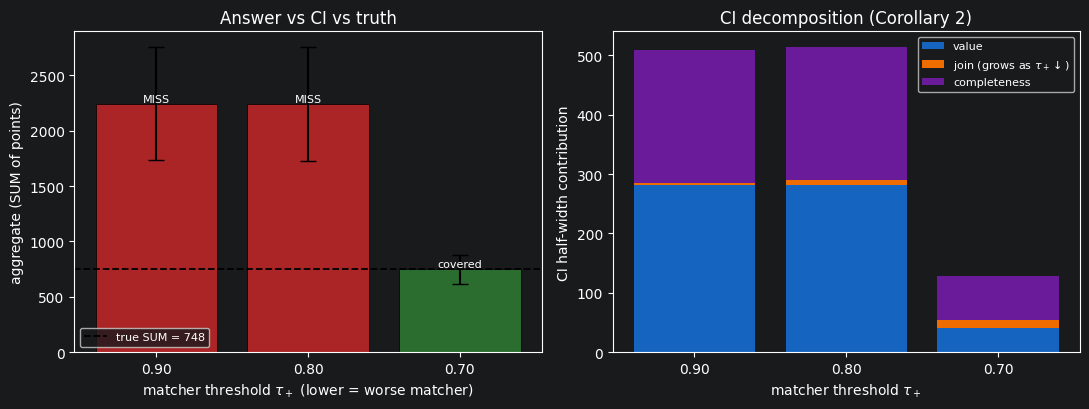

In [37]:
%matplotlib inline
fig = eval_er.plot_experiment3(df, out_path=str(REPO / "figures" / "exp3_er_propagation.pdf"))

## Step 8 — Verdict

In [38]:
n_cov, n = int(df["covered"].sum()), len(df)
pass_bar = 1 - DELTA
ppg, ppg_ci = df["mean"].iloc[0], df["mean_ci"].iloc[0]
print(f"coverage : {n_cov}/{n} thresholds covered true SUM = {gt['true_sum']:g}")
print(f"pass     : {n_cov/n >= pass_bar}   (criterion: coverage >= {pass_bar:.0%})")
print(f"join term: widened {df['join_term'].iloc[0]:.2f} -> {df['join_term'].iloc[-1]:.2f} "
      f"as tau_plus {df['tau_plus'].iloc[0]} -> {df['tau_plus'].iloc[-1]}  (Theorem 4 responding to a worse matcher)")
print(f"\nHEADLINE ANSWER: LeBron 2018 playoff PPG = {ppg:.2f} +/- {ppg_ci:.2f}  (true {gt['true_mean']:.2f})")

coverage : 1/3 thresholds covered true SUM = 748
pass     : False   (criterion: coverage >= 90%)
join term: widened 3.40 -> 13.60 as tau_plus 0.9 -> 0.7  (Theorem 4 responding to a worse matcher)

HEADLINE ANSWER: LeBron 2018 playoff PPG = 34.00 +/- 7.72  (true 34.00)


## Reusing this notebook for other queries
Everything is parameterized by the **ground‑truth file** + a **record‑field spec** `{"key": [...], "aggregate": "...", "entity": ... }`:
`key` = the attributes that identify one record, `aggregate` = the single numeric attribute to SUM, `entity` = the field carrying the entity surface (or `None` for single‑entity queries). `load_ground_truth` auto‑detects `single_entity` by counting distinct `entity_canonical`, so you don't set it by hand.

The cell below is a ready template for the multi‑entity **Alphabet** query already in the repo. Note it routes through `cluster_entities` (entity resolution driven by the swept $\tau_+$), which needs `sentence-transformers` + `torch` installed — unlike the single‑entity LeBron path, which avoids them.

In [39]:
# --- Template: multi-entity Alphabet subsidiaries (uncomment to run) -------------------------
# A round is identified within a subsidiary by its date; we SUM the amount; the LLM also
# extracts an entity_surface per record so subsidiaries can be resolved.
# ALPHABET_FIELDS = {"key": ["date"], "aggregate": "amount", "entity": "entity_surface"}
# df_a, corpus_a, gt_a, _ = eval_er.run_experiment(
#     "Total funding raised across all subsidiaries of Alphabet Inc.",
#     str(REPO / "data" / "ground_truth" / "alphabet_subsidiaries.json"),
#     run_id="exp3_alphabet",
#     record_fields=ALPHABET_FIELDS,
#     taus=(0.9, 0.8, 0.7), eps=0.10,
#     figure_path=str(REPO / "figures" / "exp3_alphabet.pdf"),
# )
# df_a   # multi-entity -> the realized SUM itself drifts with tau_plus, so coverage is the binding check